# OCTA - DenseNet121 Advanced | 3 Sinif | Final Colab

Bu notebook `OCTA-3CLASS/OCTA_DenseNet121_3sinif_Colab.ipynb` akisini final proje icin daha guclu bir DenseNet121 deneyine donusturur.

Korunan ana yapi:

- DenseNet121 ImageNet pretrained backbone
- Focal Loss
- WeightedRandomSampler
- Ayni `split_3sinif.json` ile hasta bazli train/val/test ayrimi
- Image-level ve patient-level rapor

Gelistirilen noktalar:

- Daha guclu classifier head
- Daha uzun egitim ve daha sabirli early stopping
- RandAugment, RandomResizedCrop, RandomErasing
- Daha yuksek MixUp orani
- Macro-F1 + balanced accuracy + DR/AMD recall odakli checkpoint secimi
- Colab Drive uzerinde duzenli final cikti klasoru

Beklenen Colab Drive yapisi:

```text
MyDrive/bitirme/data/OCTA
MyDrive/bitirme/data/Textlabels.xlsx
MyDrive/bitirme/data/split_3sinif.json
```

Egitim local cache'den okur, sonuclar Drive'daki `MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab` altina yazilir.


In [ ]:
# -- HUCRE 1: Drive, kurulum ve kutuphaneler ------------------------
from google.colab import drive
drive.mount('/content/drive')

!pip -q install openpyxl scikit-learn seaborn tqdm

import csv
import json
import random
import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

print('Kutuphaneler hazir.')


Mounted at /content/drive
Kutuphaneler hazir.


In [ ]:
# -- HUCRE 2: Colab local cache, yollar ve sabitler -----------------
DRIVE_BASE = Path('/content/drive/MyDrive/bitirme')
DRIVE_DATA = DRIVE_BASE / 'data'
DRIVE_OCTA = DRIVE_DATA / 'OCTA'
DRIVE_EXCEL = DRIVE_DATA / 'Textlabels.xlsx'
SPLIT_PATH = DRIVE_DATA / 'split_3sinif.json'

SAVE_DIR = DRIVE_BASE / 'outputs' / 'densenet121_advanced_3sinif_colab'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE = Path('/content/bitirme_cache_densenet121_advanced_3class')
LOCAL_DATA = LOCAL_BASE / 'data'
LOCAL_OCTA = LOCAL_DATA / 'OCTA'
LOCAL_EXCEL = LOCAL_DATA / 'Textlabels.xlsx'

required_paths = [DRIVE_OCTA, DRIVE_EXCEL, SPLIT_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        'Drive veri yolu eksik. Beklenen yapi: '
        'MyDrive/bitirme/data/OCTA, Textlabels.xlsx, split_3sinif.json. '
        f'Eksik: {missing_paths}'
    )

CLASS_NAMES = ['NORMAL', 'DR', 'AMD']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 40
MAX_LR = 8e-4
PATIENCE = 10
FREEZE_EPOCHS = 2
MIXUP_ALPHA = 0.25
MIXUP_PROB = 0.45
SEED = 42
AMP = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise RuntimeError('GPU aktif degil. Colab > Runtime > Change runtime type > GPU sec.')

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Drive veri klasoru: {DRIVE_DATA}')
print(f'Local cache klasoru: {LOCAL_DATA}')
print(f'Ortak split: {SPLIT_PATH}')
print(f'Cikti klasoru: {SAVE_DIR}')


GPU: Tesla T4
Drive veri klasoru: /content/drive/MyDrive/bitirme/data
Local cache klasoru: /content/bitirme_cache_densenet121_advanced_3class/data
Ortak split: /content/drive/MyDrive/bitirme/data/split_3sinif.json
Cikti klasoru: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab


In [ ]:
# -- HUCRE 3: Yardimci siniflar ve fonksiyonlar ---------------------
def clean_patient_id(x):
    if pd.isna(x):
        return None
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    s = str(x).strip()
    if s.endswith('.0') and s[:-2].isdigit():
        s = s[:-2]
    return s


def norm_label(x):
    return str(x).strip().upper()


def natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(path))]


def find_col(columns, candidates):
    lower_map = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise ValueError(f'Beklenen kolon bulunamadi. Adaylar={candidates}, mevcut={list(columns)}')


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.register_buffer(
            'alpha',
            torch.tensor(alpha, dtype=torch.float32) if alpha is not None else None,
        )

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = ((1.0 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            loss = alpha.gather(0, targets.view(-1)) * loss
        if self.reduction == 'sum':
            return loss.sum()
        return loss.mean()


class EyeDataset(Dataset):
    def __init__(self, dataframe, transform=None, return_patient=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.return_patient = return_patient

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label'])
        if self.return_patient:
            return image, label, str(row['patient_id'])
        return image, label


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    return mixed_x, y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


def freeze_backbone(m):
    for name, param in m.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False


def unfreeze_backbone(m):
    for param in m.parameters():
        param.requires_grad = True


def safe_macro_auc(labels, probs):
    try:
        labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
        return roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except Exception:
        return float('nan')


def summarize_metrics(labels, preds, probs, level, decision):
    row = {
        'level': level,
        'decision': decision,
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall': recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1': f1_score(labels, preds, average='macro', zero_division=0),
    }
    if probs is not None:
        row['macro_auc_ovr'] = safe_macro_auc(labels, probs)
    for idx, class_name in enumerate(CLASS_NAMES):
        key = class_name.lower()
        row[f'{key}_recall'] = recall_score(labels, preds, labels=[idx], average=None, zero_division=0)[0]
        row[f'{key}_f1'] = f1_score(labels, preds, labels=[idx], average=None, zero_division=0)[0]
    return row


print('Yardimci fonksiyonlar hazir.')


Yardimci fonksiyonlar hazir.


In [ ]:
# -- HUCRE 4: Veri yukleme - CNV filtreleme - split okuma -----------
LOCAL_DATA.mkdir(parents=True, exist_ok=True)
LOCAL_OCTA.mkdir(parents=True, exist_ok=True)
shutil.copy2(DRIVE_EXCEL, LOCAL_EXCEL)

df_raw = pd.read_excel(LOCAL_EXCEL)
df_raw.columns = df_raw.columns.str.strip()
id_col = find_col(df_raw.columns, ['ID', 'Id', 'Patient ID', 'PatientID', 'Hasta ID', 'Hasta No'])
disease_col = find_col(df_raw.columns, ['Disease', 'Diagnosis', 'Class', 'Label', 'Hastalik'])

df = df_raw[[id_col, disease_col]].copy()
df.columns = ['patient_id', 'disease']
df['patient_id'] = df['patient_id'].map(clean_patient_id)
df['disease'] = df['disease'].map(norm_label)
df = (
    df[df['disease'].isin(CLASS_NAMES)]
    .dropna(subset=['patient_id', 'disease'])
    .drop_duplicates('patient_id')
    .reset_index(drop=True)
)
df['label'] = df['disease'].map(CLASS_TO_IDX).astype(int)

print(f'CNV cikarildi -> kalan hasta: {len(df)}')
print(df['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0))

FORCE_RECOPY = False
copied, skipped, missing = 0, 0, []
for pid in tqdm(sorted(df['patient_id'].unique(), key=natural_key), desc='Drive -> local cache'):
    src_dir = DRIVE_OCTA / pid
    dst_dir = LOCAL_OCTA / pid
    if not src_dir.exists():
        missing.append(pid)
        continue

    src_count = len(list(src_dir.glob('*.bmp')))
    dst_count = len(list(dst_dir.glob('*.bmp'))) if dst_dir.exists() else -1
    if FORCE_RECOPY or (not dst_dir.exists()) or (src_count != dst_count):
        if dst_dir.exists():
            shutil.rmtree(dst_dir)
        shutil.copytree(src_dir, dst_dir)
        copied += 1
    else:
        skipped += 1

if missing:
    raise FileNotFoundError(f'Drive OCTA icinde hasta klasoru eksik: {missing[:10]}')

records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Goruntu listesi'):
    pid = row['patient_id']
    files = sorted((LOCAL_OCTA / pid).glob('*.bmp'), key=natural_key)
    for img_file in files:
        records.append(
            {
                'img_path': str(img_file),
                'path': str(img_file),
                'label': int(row['label']),
                'disease': row['disease'],
                'patient_id': pid,
            }
        )

img_df = pd.DataFrame(records)
if img_df.empty:
    raise RuntimeError(f'Goruntu bulunamadi: {LOCAL_OCTA}')

assert df['patient_id'].nunique() == 195, f'Beklenen 195 hasta, bulundu: {df["patient_id"].nunique()}'
assert img_df['patient_id'].nunique() == 195, f'Goruntulu hasta sayisi hatali: {img_df["patient_id"].nunique()}'
assert len(img_df) == 59280, f'Beklenen 59280 goruntu, bulundu: {len(img_df)}'
patient_image_counts = img_df.groupby('patient_id').size()
assert patient_image_counts.min() == 304 and patient_image_counts.max() == 304, patient_image_counts.describe()

print('Kopyalanan:', copied, 'Atlanan:', skipped)

with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
    split = json.load(f)

train_ids = set(clean_patient_id(pid) for pid in split['train'])
val_ids = set(clean_patient_id(pid) for pid in split['val'])
test_ids = set(clean_patient_id(pid) for pid in split['test'])

if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
    raise RuntimeError('Split dosyasinda hasta sizintisi var.')

all_split_ids = train_ids | val_ids | test_ids
all_patient_ids = set(df['patient_id'])
if all_split_ids != all_patient_ids:
    raise RuntimeError(
        f'Split hasta listesi ile Excel uyusmuyor. '
        f'Splitte olup Excelde olmayan: {sorted(all_split_ids - all_patient_ids)[:10]}, '
        f'Excelde olup splitte olmayan: {sorted(all_patient_ids - all_split_ids)[:10]}'
    )

train_df = img_df[img_df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = img_df[img_df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df = img_df[img_df['patient_id'].isin(test_ids)].reset_index(drop=True)

print(f'Toplam goruntu: {len(img_df)}')
print(f'Toplam hasta  : {img_df["patient_id"].nunique()}')
print(f'Train: {len(train_df):>6} goruntu | {train_df["patient_id"].nunique()} hasta')
print(f'Val  : {len(val_df):>6} goruntu | {val_df["patient_id"].nunique()} hasta')
print(f'Test : {len(test_df):>6} goruntu | {test_df["patient_id"].nunique()} hasta')

for name, part in [('TRAIN', train_df), ('VAL', val_df), ('TEST', test_df)]:
    patient_counts = part.drop_duplicates('patient_id')['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    image_counts = part['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f'\n{name} hasta dagilimi:')
    print(patient_counts)
    print(f'{name} goruntu dagilimi:')
    print(image_counts)


CNV cikarildi -> kalan hasta: 195
disease
NORMAL    160
DR         29
AMD         6
Name: count, dtype: int64


Drive -> local cache:   0%|          | 0/195 [00:00<?, ?it/s]

Goruntu listesi:   0%|          | 0/195 [00:00<?, ?it/s]

Kopyalanan: 195 Atlanan: 0
Toplam goruntu: 59280
Toplam hasta  : 195
Train:  40128 goruntu | 132 hasta
Val  :   7296 goruntu | 24 hasta
Test :  11856 goruntu | 39 hasta

TRAIN hasta dagilimi:
disease
NORMAL    108
DR         20
AMD         4
Name: count, dtype: int64
TRAIN goruntu dagilimi:
disease
NORMAL    32832
DR         6080
AMD        1216
Name: count, dtype: int64

VAL hasta dagilimi:
disease
NORMAL    20
DR         3
AMD        1
Name: count, dtype: int64
VAL goruntu dagilimi:
disease
NORMAL    6080
DR         912
AMD        304
Name: count, dtype: int64

TEST hasta dagilimi:
disease
NORMAL    32
DR         6
AMD        1
Name: count, dtype: int64
TEST goruntu dagilimi:
disease
NORMAL    9728
DR        1824
AMD        304
Name: count, dtype: int64


In [ ]:
# -- HUCRE 5: Augmentation, dataset ve sampler ----------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 24, IMG_SIZE + 24)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.82, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=10),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ColorJitter(brightness=0.12, contrast=0.14, saturation=0.05, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

label_counts = train_df['label'].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0).values.astype(np.float32)
class_weights = len(train_df) / (NUM_CLASSES * np.maximum(label_counts, 1))
class_weights[1] *= 1.35
class_weights[2] *= 1.15

print('Sinif agirliklari:')
for name, weight in zip(CLASS_NAMES, class_weights):
    print(f'  {name}: {weight:.4f}')

train_dataset = EyeDataset(train_df, transform=train_transform)
val_dataset = EyeDataset(val_df, transform=eval_transform)
test_dataset = EyeDataset(test_df, transform=eval_transform, return_patient=True)

sample_weights = train_df['label'].map({i: class_weights[i] for i in range(NUM_CLASSES)}).values.astype(np.float32)
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

NUM_WORKERS = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoader, WeightedRandomSampler, RandAugment ve MixUp hazir.')


Sinif agirliklari:
  NORMAL: 0.4074
  DR: 2.9700
  AMD: 12.6500
DataLoader, WeightedRandomSampler, RandAugment ve MixUp hazir.


In [ ]:
# -- HUCRE 6: DenseNet121 model, loss, optimizer --------------------
weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.45),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.30),
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(128),
    nn.Dropout(p=0.15),
    nn.Linear(128, NUM_CLASSES),
)
model = model.to(device)

focal_criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)

def combined_loss(outputs, labels):
    return focal_criterion(outputs, labels)

freeze_backbone(model)

backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params = list(model.classifier.parameters())

optimizer = optim.AdamW(
    [
        {'params': backbone_params, 'lr': MAX_LR / 15},
        {'params': head_params, 'lr': MAX_LR},
    ],
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[MAX_LR / 15, MAX_LR],
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos',
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP)
CHECKPOINT = SAVE_DIR / 'densenet121_advanced_best_macrof1_balacc.pth'

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Toplam parametre  : {total_params:,}')
print(f'Egitilebilir param: {trainable_params:,} (ilk {FREEZE_EPOCHS} epoch backbone donuk)')
print(f'Checkpoint        : {CHECKPOINT}')


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 165MB/s]


Toplam parametre  : 7,545,987
Egitilebilir param: 592,131 (ilk 2 epoch backbone donuk)
Checkpoint        : /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab/densenet121_advanced_best_macrof1_balacc.pth


In [ ]:
# -- HUCRE 7: Egitim dongusu - Macro F1 odakli ----------------------
history = []
best_score = -1.0
best_val_loss = float('inf')
patience_counter = 0

def evaluate_loader(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all = [], []
    probs_all = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='val', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=AMP):
                outputs = model(images)
                loss = combined_loss(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            total_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    labels_all = np.array(labels_all)
    preds_all = np.array(preds_all)
    probs_all = np.array(probs_all)
    return {
        'loss': total_loss / total,
        'acc': correct / total,
        'macro_f1': f1_score(labels_all, preds_all, average='macro', zero_division=0),
        'bal_acc': balanced_accuracy_score(labels_all, preds_all),
        'dr_recall': recall_score(labels_all, preds_all, labels=[1], average=None, zero_division=0)[0],
        'amd_recall': recall_score(labels_all, preds_all, labels=[2], average=None, zero_division=0)[0],
        'auc': safe_macro_auc(labels_all, probs_all),
    }

print('EGITIM BASLIYOR...')
print(f'{"Epoch":>5} | {"TrLoss":>8} | {"TrAcc":>7} | {"ValLoss":>8} | {"ValAcc":>7} | {"MacroF1":>8} | {"BalAcc":>7} | Durum')
print('-' * 108)

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_backbone(model)
        print(f'  Epoch {epoch}: backbone acildi, fine-tuning basliyor.')

    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    counted_total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        use_mixup = np.random.rand() < MIXUP_PROB
        with torch.cuda.amp.autocast(enabled=AMP):
            if use_mixup:
                mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)
                outputs = model(mixed_images)
                loss = mixup_criterion(combined_loss, outputs, labels_a, labels_b, lam)
            else:
                outputs = model(images)
                loss = combined_loss(outputs, labels)
                tr_correct += (outputs.argmax(1) == labels).sum().item()
                counted_total += images.size(0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        tr_loss += loss.item() * images.size(0)
        tr_total += images.size(0)

    train_loss = tr_loss / tr_total
    train_acc = (tr_correct / counted_total) if counted_total > 0 else 0.0
    val_metrics = evaluate_loader(val_loader)

    score = val_metrics['macro_f1'] + 0.12 * val_metrics['bal_acc'] + 0.05 * val_metrics['dr_recall'] + 0.03 * val_metrics['amd_recall']
    improved = score > best_score or (np.isclose(score, best_score) and val_metrics['loss'] < best_val_loss)

    if improved:
        best_score = score
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'classes': CLASS_NAMES,
                'epoch': epoch,
                'best_score': best_score,
                'val_metrics': val_metrics,
            },
            CHECKPOINT,
        )
        status = 'BEST'
    else:
        patience_counter += 1
        status = f'wait {patience_counter}/{PATIENCE}'

    history.append(
        {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['acc'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_bal_acc': val_metrics['bal_acc'],
            'val_dr_recall': val_metrics['dr_recall'],
            'val_amd_recall': val_metrics['amd_recall'],
            'val_auc': val_metrics['auc'],
            'score': score,
        }
    )

    print(
        f'{epoch:5d} | {train_loss:8.4f} | {train_acc*100:6.2f}% | '
        f'{val_metrics["loss"]:8.4f} | {val_metrics["acc"]*100:6.2f}% | '
        f'{val_metrics["macro_f1"]:8.4f} | {val_metrics["bal_acc"]:7.4f} | {status}'
    )

    if patience_counter >= PATIENCE:
        print(f'Erken durdurma: {PATIENCE} epoch iyilesme yok.')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(SAVE_DIR / 'history.csv', index=False)
print('Egitim tamamlandi. En iyi skor:', best_score)


EGITIM BASLIYOR...
Epoch |   TrLoss |   TrAcc |  ValLoss |  ValAcc |  MacroF1 |  BalAcc | Durum
------------------------------------------------------------------------------------------------------------


Epoch 1 train:   0%|          | 0/2508 [00:00<?, ?it/s]

val:   0%|          | 0/456 [00:00<?, ?it/s]

    1 |   2.2536 |  45.40% |   0.5628 |  12.60% |   0.1913 |  0.5274 | BEST


Epoch 2 train:   0%|          | 0/2508 [00:00<?, ?it/s]

...

   19 |   0.1728 |  98.30% |   0.4248 |  78.65% |   0.6075 |  0.6915 | wait 9/10


Epoch 20 train:   0%|          | 0/2508 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c46b28b240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c46b28b240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

val:   0%|          | 0/456 [00:00<?, ?it/s]

   20 |   0.1719 |  98.39% |   0.5152 |  83.28% |   0.6271 |  0.6467 | wait 10/10
Erken durdurma: 10 epoch iyilesme yok.
Egitim tamamlandi. En iyi skor: 0.7660676056920249


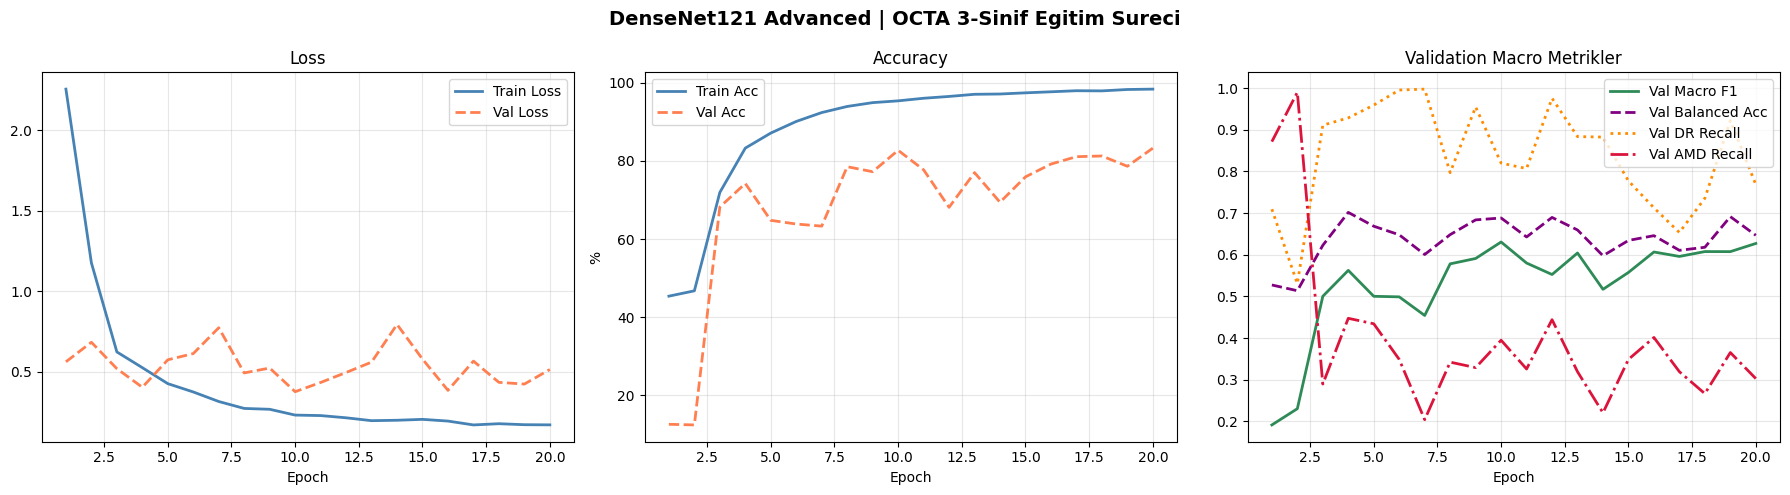

Egitim grafikleri kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab/densenet121_advanced_training_curves.png


In [ ]:
# -- HUCRE 8: Egitim grafikleri ------------------------------------
hist = pd.DataFrame(history)
epochs_x = hist['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DenseNet121 Advanced | OCTA 3-Sinif Egitim Sureci', fontsize=14, fontweight='bold')

axes[0].plot(epochs_x, hist['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_x, hist['val_loss'], label='Val Loss', color='coral', linestyle='--', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_x, hist['train_acc'] * 100, label='Train Acc', color='steelblue', linewidth=2)
axes[1].plot(epochs_x, hist['val_acc'] * 100, label='Val Acc', color='coral', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(epochs_x, hist['val_macro_f1'], label='Val Macro F1', color='seagreen', linewidth=2)
axes[2].plot(epochs_x, hist['val_bal_acc'], label='Val Balanced Acc', color='purple', linestyle='--', linewidth=2)
axes[2].plot(epochs_x, hist['val_dr_recall'], label='Val DR Recall', color='darkorange', linestyle=':', linewidth=2)
axes[2].plot(epochs_x, hist['val_amd_recall'], label='Val AMD Recall', color='crimson', linestyle='-.', linewidth=2)
axes[2].set_title('Validation Macro Metrikler')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
training_curve_path = SAVE_DIR / 'densenet121_advanced_training_curves.png'
plt.savefig(training_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print('Egitim grafikleri kaydedildi:', training_curve_path)


test:   0%|          | 0/741 [00:00<?, ?it/s]

IMAGE-LEVEL TEST RAPORU
              precision    recall  f1-score   support

      NORMAL     0.9520    0.9855    0.9685      9728
          DR     0.9496    0.7330    0.8274      1824
         AMD     0.8042    1.0000    0.8915       304

    accuracy                         0.9470     11856
   macro avg     0.9019    0.9062    0.8958     11856
weighted avg     0.9479    0.9470    0.9448     11856

Balanced Accuracy: 0.9062
Macro AUC OvR    : 0.9728


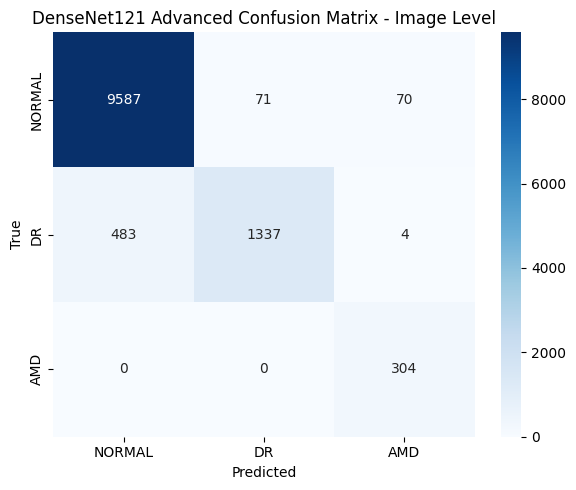

Image CM kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab/densenet121_advanced_confusion_matrix_image.png


In [ ]:
import torch

# -- HUCRE 9: Test tahminleri - image level -------------------------
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_probs, all_labels, all_patients = [], [], []
with torch.no_grad():
    for images, labels, patient_ids in tqdm(test_loader, desc='test'):
        images = images.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=AMP):
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(labels.numpy().tolist())
        all_patients.extend(list(patient_ids))

test_probs = np.concatenate(all_probs, axis=0)
test_labels = np.array(all_labels)
test_preds = test_probs.argmax(axis=1)

print('IMAGE-LEVEL TEST RAPORU')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Balanced Accuracy: {balanced_accuracy_score(test_labels, test_preds):.4f}')
print(f'Macro AUC OvR    : {safe_macro_auc(test_labels, test_probs):.4f}')

cm_img = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_img, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DenseNet121 Advanced Confusion Matrix - Image Level')
plt.tight_layout()
image_cm_path = SAVE_DIR / 'densenet121_advanced_confusion_matrix_image.png'
plt.savefig(image_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Image CM kaydedildi:', image_cm_path)

PATIENT-LEVEL TEST RAPORU
              precision    recall  f1-score   support

      NORMAL     0.9697    1.0000    0.9846        32
          DR     1.0000    0.8333    0.9091         6
         AMD     1.0000    1.0000    1.0000         1

    accuracy                         0.9744        39
   macro avg     0.9899    0.9444    0.9646        39
weighted avg     0.9751    0.9744    0.9734        39

Patient Balanced Accuracy: 0.9444


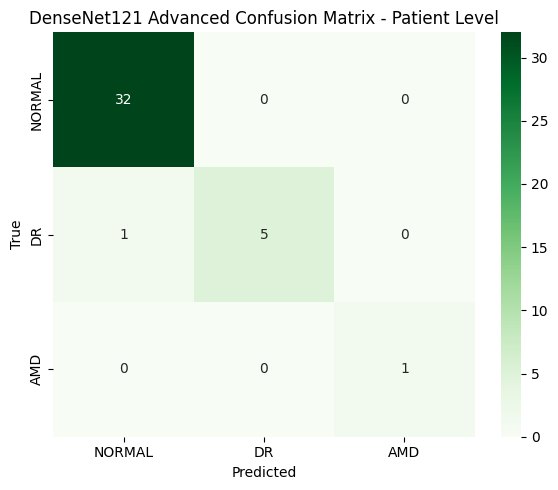

Patient CM kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab/densenet121_advanced_confusion_matrix_patient.png


In [ ]:
# -- HUCRE 10: Patient-level degerlendirme --------------------------
test_probs_df = test_df.copy().reset_index(drop=True)
test_probs_df['patient_id'] = list(all_patients)
test_probs_df['true'] = test_labels
test_probs_df['p_normal'] = test_probs[:, 0]
test_probs_df['p_dr'] = test_probs[:, 1]
test_probs_df['p_amd'] = test_probs[:, 2]

patient_df = (
    test_probs_df
    .groupby('patient_id')
    .agg({
        'true': 'first',
        'disease': 'first',
        'p_normal': 'mean',
        'p_dr': 'mean',
        'p_amd': 'mean',
        'img_path': 'count',
    })
    .rename(columns={'img_path': 'image_count'})
    .reset_index()
)

patient_true = patient_df['true'].values
patient_probs = patient_df[['p_normal', 'p_dr', 'p_amd']].values
patient_preds = patient_probs.argmax(axis=1)

patient_df['pred'] = [CLASS_NAMES[idx] for idx in patient_preds]
patient_df.to_csv(SAVE_DIR / 'densenet121_advanced_patient_predictions.csv', index=False)

print('PATIENT-LEVEL TEST RAPORU')
print('=' * 70)
print(classification_report(patient_true, patient_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f'Patient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds):.4f}')

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DenseNet121 Advanced Confusion Matrix - Patient Level')
plt.tight_layout()
patient_cm_path = SAVE_DIR / 'densenet121_advanced_confusion_matrix_patient.png'
plt.savefig(patient_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Patient CM kaydedildi:', patient_cm_path)


In [ ]:
# -- HUCRE 11: Metrik tablosu ve rapor dosyasi -----------------------
metrics_summary = pd.DataFrame(
    [
        summarize_metrics(test_labels, test_preds, test_probs, level='image', decision='argmax'),
        summarize_metrics(patient_true, patient_preds, patient_probs, level='patient', decision='mean_argmax'),
    ]
)
preferred_cols = [
    'level',
    'decision',
    'accuracy',
    'balanced_accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'macro_auc_ovr',
    'normal_recall',
    'dr_recall',
    'amd_recall',
    'normal_f1',
    'dr_f1',
    'amd_f1',
]
metrics_summary = metrics_summary[[col for col in preferred_cols if col in metrics_summary.columns]]
metrics_path = SAVE_DIR / 'metrics_summary.csv'
metrics_summary.to_csv(metrics_path, index=False)

report_path = SAVE_DIR / 'test_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('DenseNet121 Advanced | OCTA 3-Sinif | Final Colab\n')
    f.write('=' * 70 + '\n\n')
    f.write('IMAGE-LEVEL REPORT\n')
    f.write(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nBalanced Accuracy: {balanced_accuracy_score(test_labels, test_preds):.4f}\n')
    f.write(f'Macro AUC OvR    : {safe_macro_auc(test_labels, test_probs):.4f}\n\n')
    f.write('PATIENT-LEVEL REPORT\n')
    f.write(classification_report(patient_true, patient_preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nPatient Balanced Accuracy: {balanced_accuracy_score(patient_true, patient_preds):.4f}\n\n')
    f.write('IMAGE CM\n')
    f.write(np.array2string(cm_img) + '\n\n')
    f.write('PATIENT CM\n')
    f.write(np.array2string(cm_patient) + '\n')

print('Metrik tablosu kaydedildi:', metrics_path)
print('Rapor kaydedildi:', report_path)
display(metrics_summary.round(4))


Metrik tablosu kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab/metrics_summary.csv
Rapor kaydedildi: /content/drive/MyDrive/bitirme/outputs/densenet121_advanced_3sinif_colab/test_report.txt


,level,decision,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr,normal_recall,dr_recall,amd_recall,normal_f1,dr_f1,amd_f1
0,image,argmax,0.9470,0.9062,0.9019,0.9062,0.8958,0.9728,0.9855,0.7330,1.0,0.9685,0.8274,0.8915
1,patient,mean_argmax,0.9744,0.9444,0.9899,0.9444,0.9646,1.0000,1.0000,0.8333,1.0,0.9846,0.9091,1.0000


## Not

Bu notebook mevcut DenseNet121 deneyinin daha agresif final Colab surumudur. Ana rapor icin hasta bazli Macro-F1 ve Balanced Accuracy oncelikli okunmalidir. AMD test hasta sayisi dusuk oldugu icin AMD hasta-bazli recall sonucu raporda bu sinirla birlikte yorumlanmalidir.
